<a href="https://colab.research.google.com/github/nadiia2302/python_for_ds_tasks/blob/main/HW_11_2_Data_Visualization_with_Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [ ]:
count_by_mean = df['count'].resample('ME').mean()

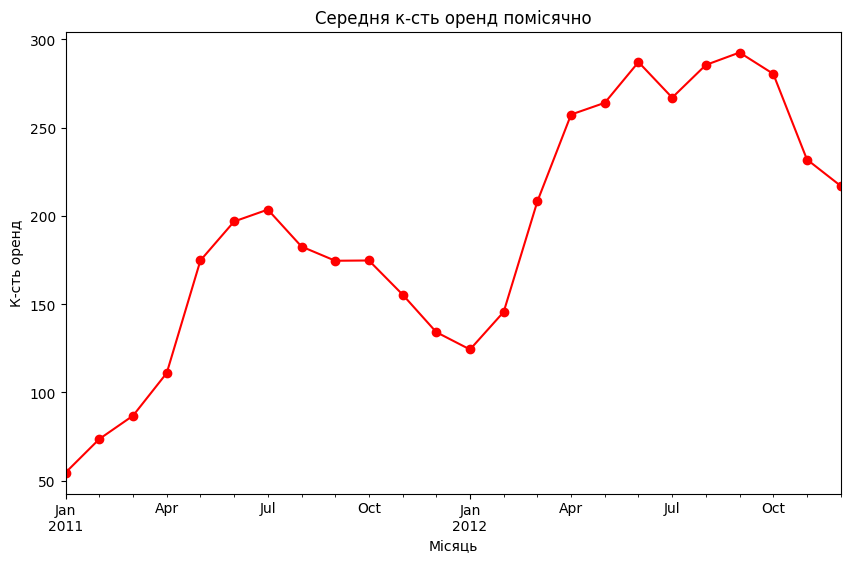

In [ ]:
# with Pandas
count_by_mean.plot(
    marker = 'o',
    color ='red',
    figsize=(10,6),
    title = 'Середня к-сть оренд помісячно',
    xlabel = 'Місяць',
    ylabel = 'К-сть оренд'
);


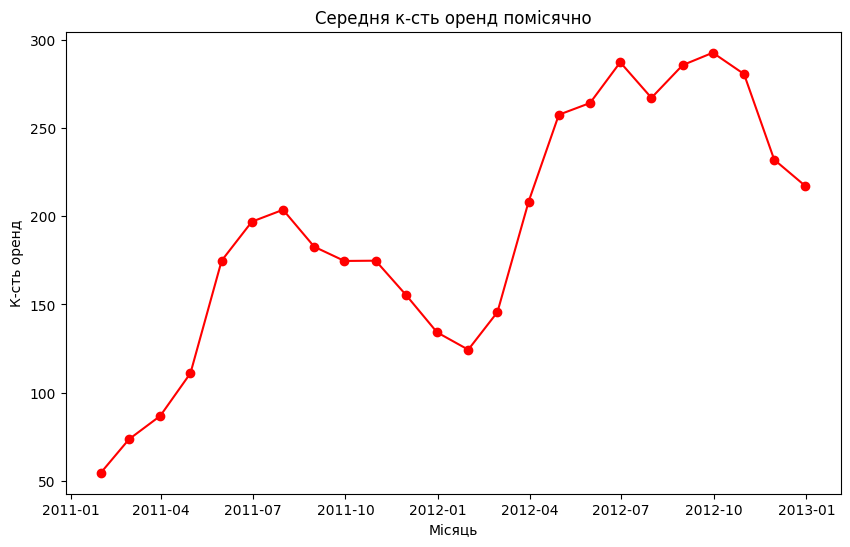

In [ ]:
# with Matplotlib
plt.figure(figsize = (10,6))
plt.plot(count_by_mean,'o-r')
plt.title('Середня к-сть оренд помісячно')
plt.xlabel('Місяць')
plt.ylabel('К-сть оренд');

В Пандасі початок візуалізації йде від 0, в Матплотлібі - ні. І по осі X різна інтерпретація місяців. В Matplotlib кращий візуально графік.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [ ]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

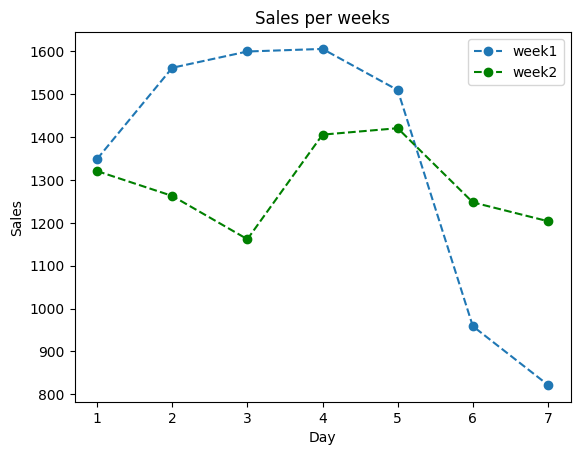

In [ ]:
plt.plot(days, sales_week1,'o--', label = 'week1')
plt.plot(days, sales_week2, 'o--g', label = 'week2')
plt.title("Sales per weeks")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.legend();

На другому тижні продажі були стабільніші, ніж у першому. Через те, що на першому тижні продажі повністю різко зменшилися вниз по графіку, я не можу вважати їх стабільними.


In [ ]:
import statistics
a = [2, 4, 6, 8, 10]

avg = statistics.mean(a)
print(avg)

6


In [ ]:
std_sales_1 = np.std(sales_week1)
print("Standard deviation per week 1 is", round(std_sales_1,2))
std_sales_2 = np.std(sales_week2)
print("Standard deviation per week 2 is", round(std_sales_2,2))

Standard deviation per week 1 is 300.0
Standard deviation per week 2 is 90.91


In [ ]:
range_week1 = max(sales_week1) - min(sales_week1)
range_week2 = max(sales_week2) - min(sales_week2)
print("Week 1 range is", range_week1)
print("Week 2 range is", range_week2)

Week 1 range is 784
Week 2 range is 259


Порівнюючи за стандартним відхиленням і розмахом, бачимо, що продажі на другому тижні, стабільніші, ніж в першому тижні.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [ ]:
mean_temp = df.groupby('month')['temp'].mean()

In [ ]:
df['quarter'] = df.index.quarter

In [ ]:
mean_hourly_by_quarter = df.groupby('quarter')['count'].mean()

In [ ]:
mean_hourly_by_quarter.head()

,count
quarter,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


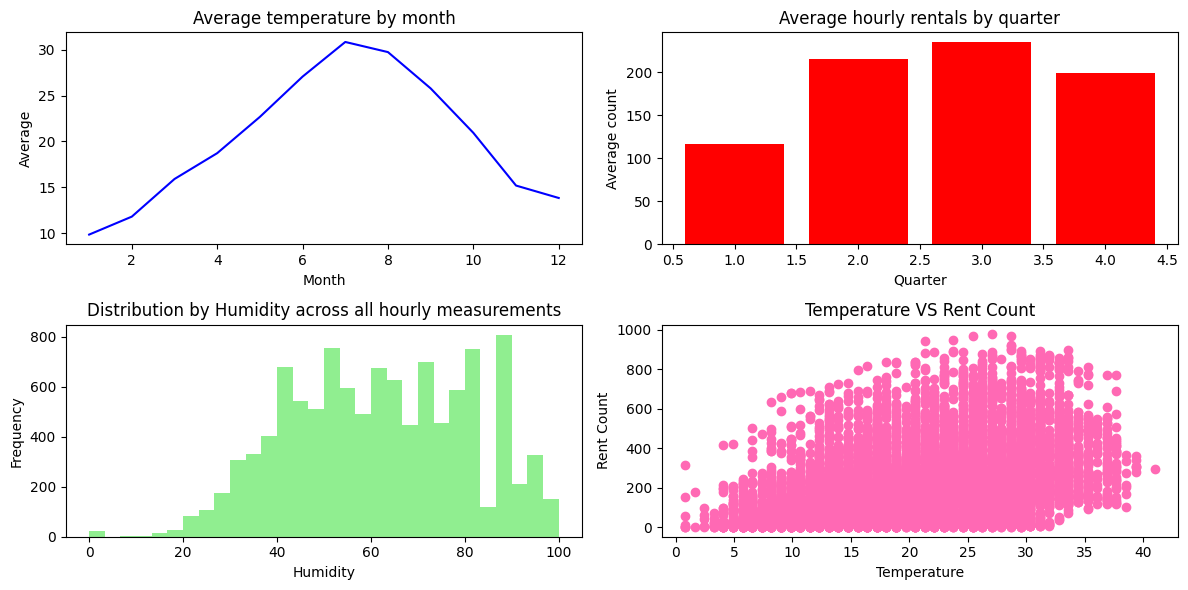

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(2, 2, 1)
plt.plot(mean_temp, color = 'blue')
plt.title('Average temperature by month')
plt.xlabel('Month')
plt.ylabel('Average')


plt.subplot(2, 2, 2)
plt.bar(mean_hourly_by_quarter.index, mean_hourly_by_quarter.values, color='red')
plt.title('Average hourly rentals by quarter')
plt.xlabel('Quarter')
plt.ylabel('Average count')

plt.subplot(2,2,3)
plt.hist(df['humidity'], bins = 30, color = 'lightgreen')
plt.title('Distribution by Humidity across all hourly measurements')
plt.xlabel('Humidity')
plt.ylabel('Frequency')

plt.subplot(2,2,4)
plt.scatter(df['temp'],df['count'], color = 'hotpink')
plt.title('Temperature VS Rent Count')
plt.xlabel('Temperature')
plt.ylabel('Rent Count');
plt.tight_layout()
plt.show();

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

plt.subplots() відрізняється від plt.subplot() тим, що є гнучнішим, легше масштабувати, є пошук по індексах (чіткий контроль)

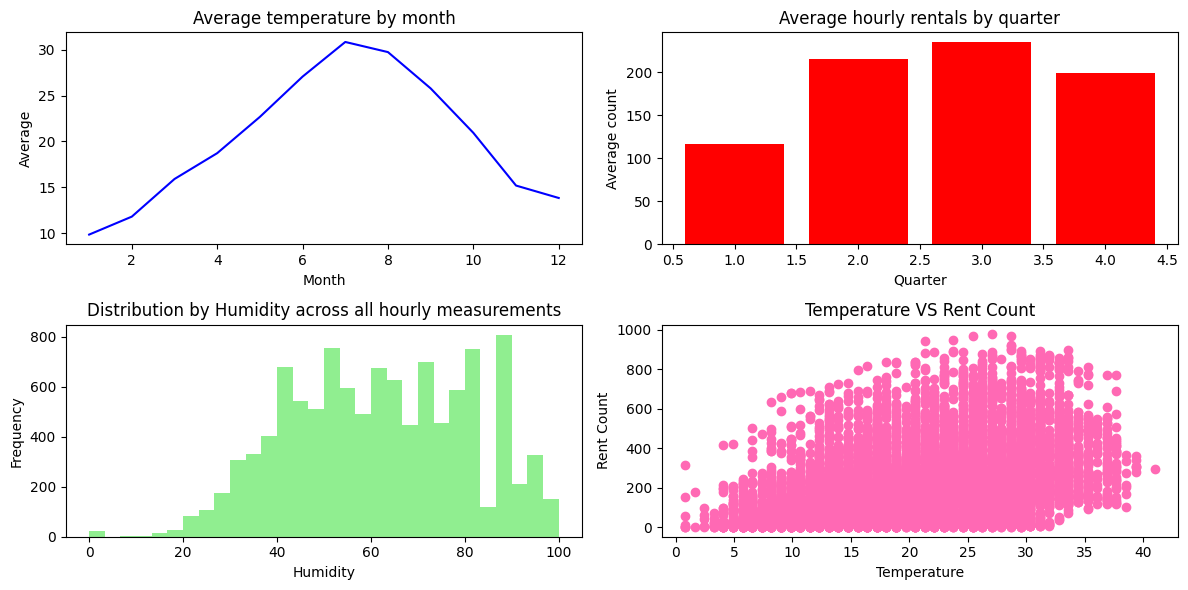

In [ ]:
fig, ax = plt.subplots(2,2,figsize = (12, 6))

ax[0, 0].plot(mean_temp,color = 'blue')
ax[0, 0].set_title('Average temperature by month')
ax[0, 0].set_xlabel('Month')
ax[0, 0].set_ylabel('Average')

ax[0, 1].bar(mean_hourly_by_quarter.index, mean_hourly_by_quarter.values, color='red')
ax[0, 1].set_title('Average hourly rentals by quarter')
ax[0, 1].set_xlabel('Quarter')
ax[0, 1].set_ylabel('Average count')

ax[1,0].hist(df['humidity'], bins = 30, color = 'lightgreen')
ax[1,0].set_title('Distribution by Humidity across all hourly measurements')
ax[1,0].set_xlabel('Humidity')
ax[1,0].set_ylabel('Frequency')

ax[1, 1].scatter(df['temp'],df['count'], color = 'hotpink')
ax[1, 1].set_title('Temperature VS Rent Count')
ax[1, 1].set_xlabel('Temperature')
ax[1, 1].set_ylabel('Rent Count')

plt.tight_layout(rect = [0, 0, 1, 1])
plt.show()

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

1. Перевага додавання анотацій на графік полягає на тому, щоб виділити важливі точки і робити пояснення на них.
2. fill_between() використовується для того, щоб зафарбувати ділянку між двома графіками
3. Текстовий блок висвітлює додаткову інформацію про статистику відразу на графіку.

In [ ]:
import matplotlib.dates as mdates

In [ ]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day,quarter
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,Saturday,5,52,2011,1,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,Saturday,5,52,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,Saturday,5,52,2011,1,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,3,Saturday,5,52,2011,1,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,4,Saturday,5,52,2011,1,1


In [ ]:
monthly_count = df['count'].resample('ME').agg(['mean','max','min'])

In [ ]:
monthly_count

,mean,max,min
datetime,,,
2011-01-31,54.645012,219,1
2011-02-28,73.641256,327,1
2011-03-31,86.849776,332,1
2011-04-30,111.026374,452,1
2011-05-31,174.809211,611,1
2011-06-30,196.877193,638,1
2011-07-31,203.614035,596,1
2011-08-31,182.666667,600,1
2011-09-30,174.622517,628,1


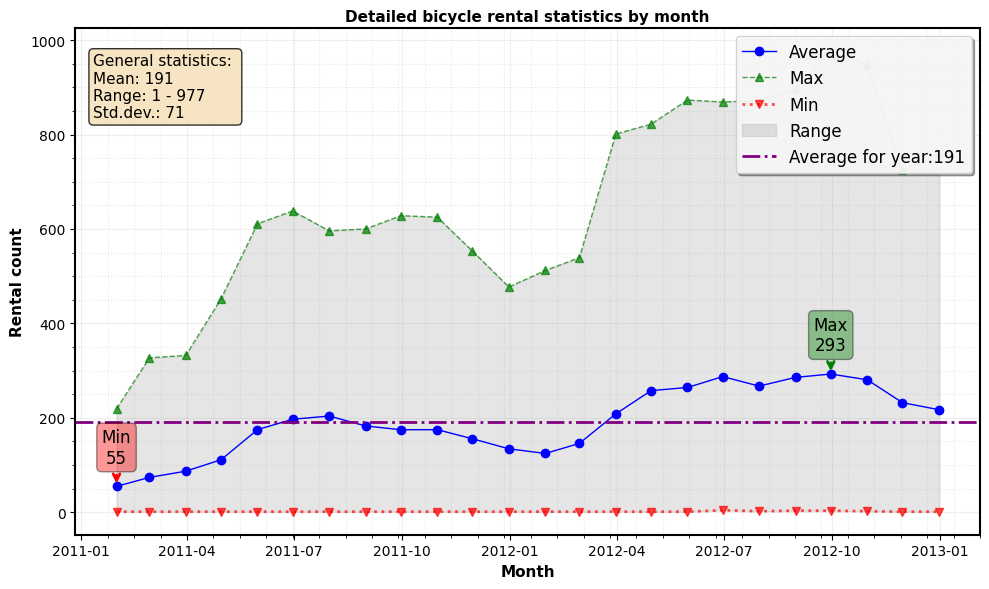

In [ ]:
from matplotlib import markers
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(monthly_count.index,monthly_count['mean'], 'b-o', linewidth = 1, label = 'Average', markersize=6)

ax.plot(monthly_count.index, monthly_count['max'], 'g--^', linewidth = 1, label = 'Max', markersize = 6, alpha = 0.7)

ax.plot(monthly_count.index, monthly_count['min'], 'r:v', linewidth = 2, label = 'Min', markersize = 6, alpha = 0.7)

ax.fill_between(monthly_count.index, monthly_count['min'], monthly_count['max'], alpha = 0.2, color = 'gray', label = 'Range')


max_idx = monthly_count['mean'].idxmax()
max_val = monthly_count['mean'].max()

min_idx = monthly_count['mean'].idxmin()
min_val = monthly_count['mean'].min()

ax.grid(True, which = 'major', linestyle = '-',alpha = 0.2)
ax.grid(True, which = 'minor', linestyle = ':', alpha = 0.3)
ax.minorticks_on()

ax.annotate(f"Max\n{max_val:.0f}",
            xy = (max_idx, max_val), xytext = (max_idx, max_val + 50),
            arrowprops=dict(arrowstyle = '->', color = 'green', lw = 2),
            fontsize = 12, ha = 'center',
            bbox = dict(boxstyle = "round, pad=0.3", facecolor = 'green', alpha = 0.4))

ax.annotate(f'Min\n{min_val:.0f}',
            xy = (min_idx, min_val), xytext=(min_idx, min_val + 50),
            arrowprops=dict(arrowstyle = '->', color = 'red', lw = 2),
            fontsize = 12, ha = 'center',
            bbox = dict(boxstyle = 'round, pad = 0.3', facecolor = 'red', alpha = 0.4))
ax.set_xlabel('Month', fontsize = 11, fontweight = 'bold')
ax.set_ylabel('Rental count', fontsize = 11, fontweight = 'bold')
ax.set_title('Detailed bicycle rental statistics by month', fontsize = 11, fontweight = 'bold', pad = 5)

overall_mean = monthly_count['mean'].mean()
ax.axhline( y = overall_mean, color = 'purple', linestyle = '-.', linewidth = 2, label = f'Average for year:{overall_mean:.0f}')

ax.legend(loc = 'upper right', fontsize = 12, frameon = True, shadow = True, fancybox = True, framealpha = 0.9)

textstr = f'General statistics: \n'
textstr += f'Mean: {monthly_count['mean'].mean():.0f}\n'
textstr += f'Range: {monthly_count['min'].min():.0f} - {monthly_count['max'].max():.0f}\n'
textstr += f'Std.dev.: {(monthly_count['mean']).std():.0f}'

props = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.8)

ax.text(0.02, 0.95, textstr, transform = ax.transAxes, fontsize = 11,
        verticalalignment = 'top', bbox = props)

for spine in ax.spines.values():
  spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()
